In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Original Shape: (76, 1)
Single-column dataset detected

Dataset Loaded Successfully

   Season              Team  LeaguePosition  Matches  Wins  Losses  NoResult  \
0  2011.0               RCB             1.0     14.0   9.0     4.0       1.0   
1  2011.0               CSK             2.0     14.0   9.0     5.0       0.0   
2  2011.0                MI             3.0     14.0   9.0     5.0       0.0   
3  2011.0               KKR             4.0     14.0   8.0     6.0       0.0   
5  2012.0  Delhi Daredevils             1.0     16.0  11.0     5.0       0.0   

   Points    NRR    C   RU  
0    19.0  0.326  0.0  1.0  
1    18.0  0.443  1.0  0.0  
2    18.0  0.040  0.0  0.0  
3    16.0  0.433  0.0  0.0  
5    22.0  0.617  0.0  0.0  

Shape: (60, 11)

Columns:
 ['Season', 'Team', 'LeaguePosition', 'Matches', 'Wins', 'Losses', 'NoResult', 'Points', 'NRR', 'C', 'RU']

Titles By Position

LeaguePosition
1.0    5
2.0    9
3.0    1
dtype: int64


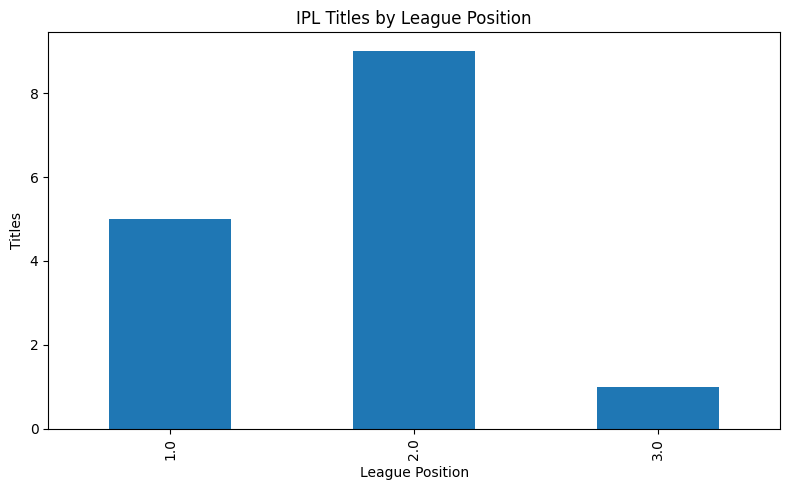

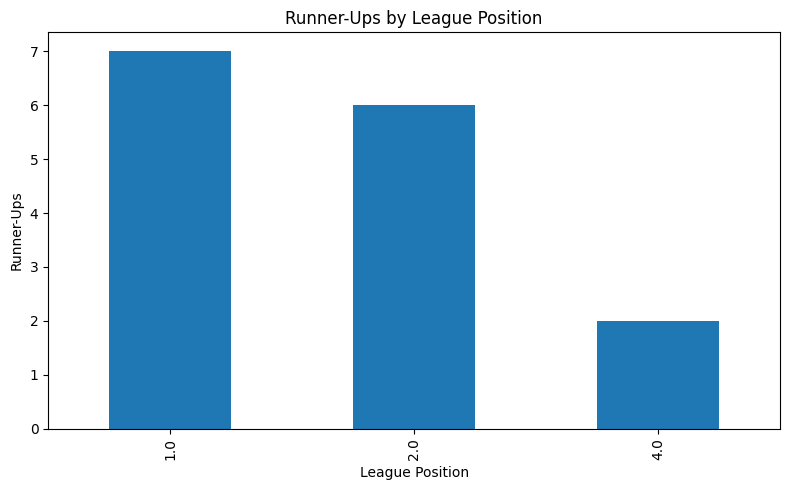


Top 2 Teams Won 93.33% of Titles

Position Success Rate (%)

LeaguePosition
1.0    33.33
2.0    60.00
3.0     6.67
4.0      NaN
Name: count, dtype: float64


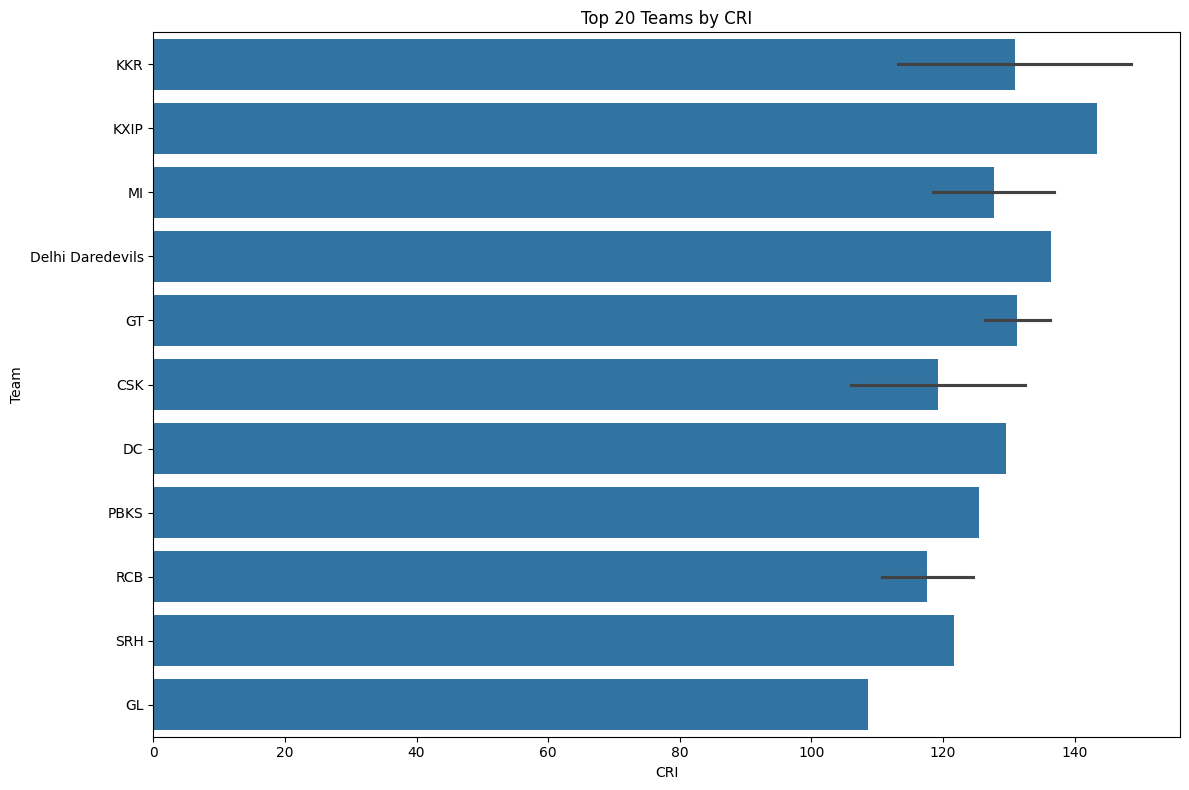

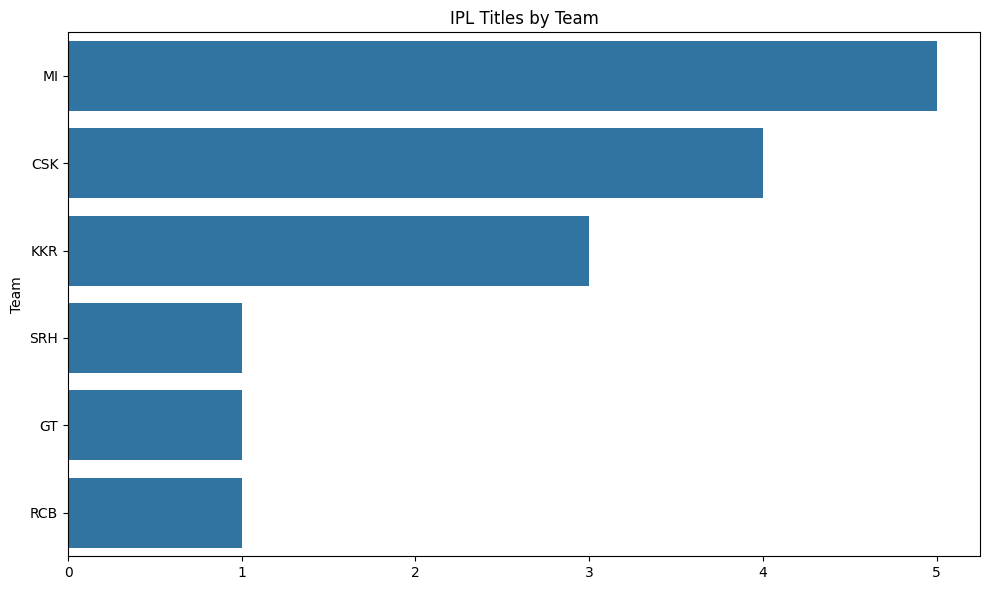

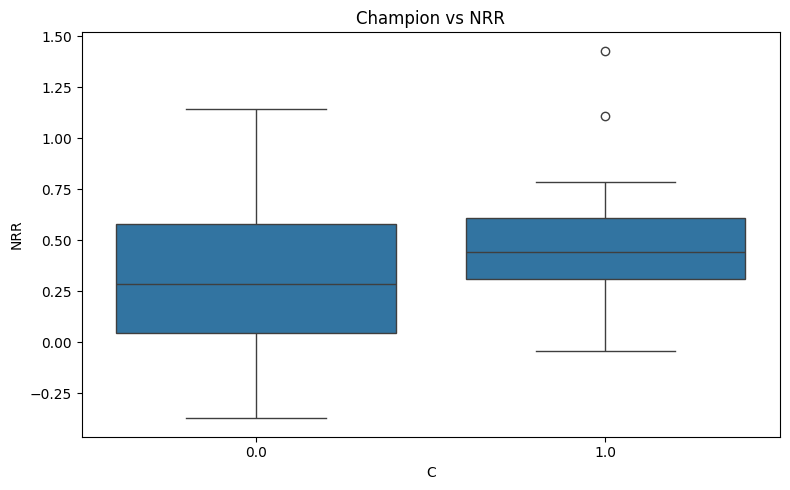

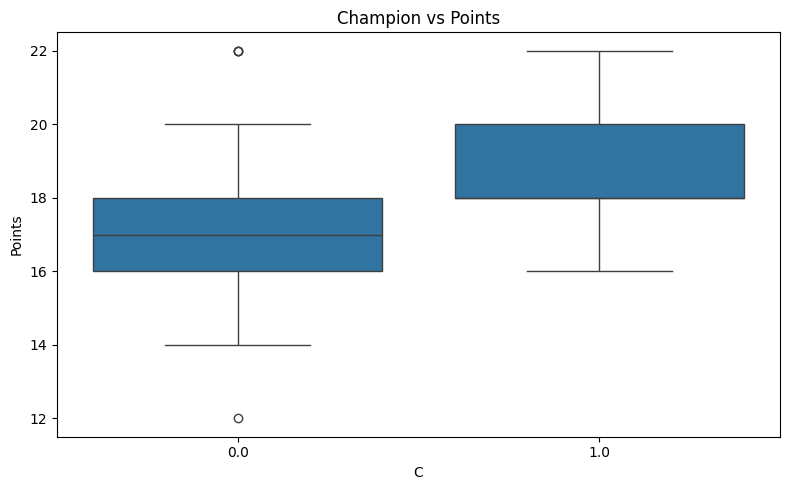

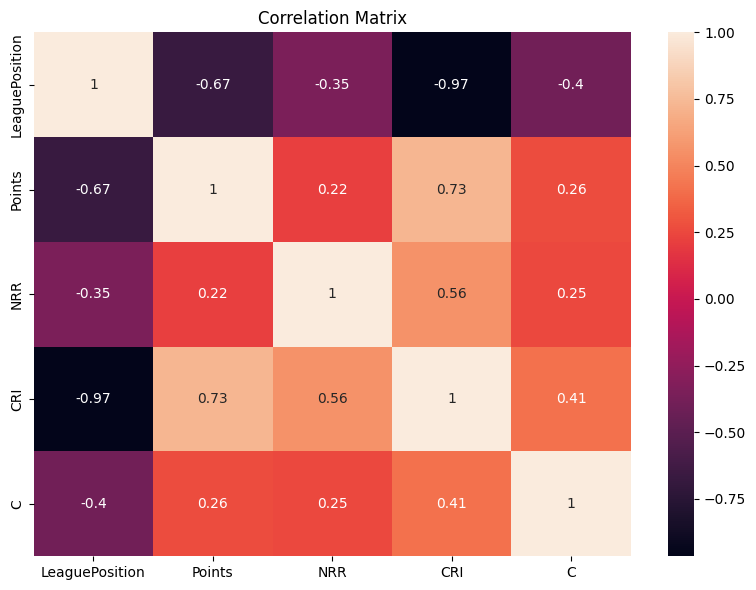


Yearly Champions

    Season Team
1   2011.0  CSK
6   2012.0  KKR
11  2013.0   MI
16  2014.0  KKR
21  2015.0   MI
28  2016.0  SRH
31  2017.0   MI
37  2018.0  CSK
41  2019.0   MI
46  2020.0   MI
53  2021.0  CSK
57  2022.0   GT
63  2023.0  CSK
67  2024.0  KKR
73  2025.0  RCB

Project Completed Successfully
Charts Folder Created
Output Folder Created
Research Dataset Exported


In [5]:
# =====================================================
# IPL CHAMPIONSHIP PREDICTION ENGINE
# =====================================================

# Install dependencies (Colab)
!pip -q install openpyxl seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =====================================================
# CREATE FOLDERS
# =====================================================

os.makedirs("charts", exist_ok=True)
os.makedirs("output", exist_ok=True)

# =====================================================
# LOAD EXCEL
# =====================================================

file_name = "IPL_Championship_Research_Dataset.xlsx"

raw = pd.read_excel(file_name)

print("Original Shape:", raw.shape)

# =====================================================
# HANDLE BOTH DATASET FORMATS
# =====================================================

if raw.shape[1] == 1:

    print("Single-column dataset detected")

    col = raw.columns[0]

    raw = raw.dropna()

    df = raw[col].astype(str).str.split(",", expand=True)

    df.columns = [
        "Season",
        "Team",
        "LeaguePosition",
        "Matches",
        "Wins",
        "Losses",
        "NoResult",
        "Points",
        "NRR",
        "C",
        "RU"
    ]

else:

    print("Multi-column dataset detected")

    df = raw.copy()

# =====================================================
# CLEAN COLUMN NAMES
# =====================================================

df.columns = [str(c).strip() for c in df.columns]

# =====================================================
# NUMERIC CONVERSION
# =====================================================

numeric_cols = [
    "Season",
    "LeaguePosition",
    "Matches",
    "Wins",
    "Losses",
    "NoResult",
    "Points",
    "NRR",
    "C",
    "RU"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

# =====================================================
# DATASET INFO
# =====================================================

print("\nDataset Loaded Successfully\n")

print(df.head())

print("\nShape:", df.shape)

print("\nColumns:\n", df.columns.tolist())

# =====================================================
# SAVE CLEAN DATASET
# =====================================================

df.to_csv(
    "output/cleaned_ipl_dataset.csv",
    index=False
)

# =====================================================
# CHAMPIONS DATA
# =====================================================

champions = df[df["C"] == 1]

runnerups = df[df["RU"] == 1]

# =====================================================
# TITLES BY POSITION
# =====================================================

titles_by_position = (
    champions
    .groupby("LeaguePosition")
    .size()
)

print("\nTitles By Position\n")

print(titles_by_position)

plt.figure(figsize=(8,5))

titles_by_position.plot(
    kind="bar"
)

plt.title("IPL Titles by League Position")

plt.xlabel("League Position")

plt.ylabel("Titles")

plt.tight_layout()

plt.savefig(
    "charts/titles_by_position.png"
)

plt.show()

# =====================================================
# RUNNER UPS BY POSITION
# =====================================================

runnerups_by_position = (
    runnerups
    .groupby("LeaguePosition")
    .size()
)

plt.figure(figsize=(8,5))

runnerups_by_position.plot(
    kind="bar"
)

plt.title("Runner-Ups by League Position")

plt.xlabel("League Position")

plt.ylabel("Runner-Ups")

plt.tight_layout()

plt.savefig(
    "charts/runnerups_by_position.png"
)

plt.show()

# =====================================================
# TOP 2 ANALYSIS
# =====================================================

top2_titles = len(
    champions[
        champions["LeaguePosition"] <= 2
    ]
)

total_titles = len(champions)

top2_percentage = (
    top2_titles /
    total_titles
) * 100

print(
    f"\nTop 2 Teams Won {top2_percentage:.2f}% of Titles"
)

# =====================================================
# POSITION SUCCESS RATE
# =====================================================

position_total = (
    df["LeaguePosition"]
    .value_counts()
    .sort_index()
)

position_titles = (
    champions["LeaguePosition"]
    .value_counts()
    .sort_index()
)

success_rate = (
    position_titles /
    position_total
) * 100

print("\nPosition Success Rate (%)\n")

print(success_rate.round(2))

# =====================================================
# CHAMPIONSHIP READINESS INDEX
# =====================================================

df["CRI"] = (

    (5 - df["LeaguePosition"]) * 20

    +

    (df["Points"] * 2)

    +

    (df["NRR"] * 20)

)

# =====================================================
# TOP CRI TEAMS
# =====================================================

top_cri = (
    df
    .sort_values(
        "CRI",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x="CRI",
    y="Team",
    data=top_cri
)

plt.title(
    "Top 20 Teams by CRI"
)

plt.tight_layout()

plt.savefig(
    "charts/top_cri_teams.png"
)

plt.show()

# =====================================================
# TEAM TITLE COUNT
# =====================================================

team_titles = (
    champions["Team"]
    .value_counts()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=team_titles.values,
    y=team_titles.index
)

plt.title(
    "IPL Titles by Team"
)

plt.tight_layout()

plt.savefig(
    "charts/team_titles.png"
)

plt.show()

# =====================================================
# NRR ANALYSIS
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="C",
    y="NRR",
    data=df
)

plt.title(
    "Champion vs NRR"
)

plt.tight_layout()

plt.savefig(
    "charts/champion_vs_nrr.png"
)

plt.show()

# =====================================================
# POINTS ANALYSIS
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="C",
    y="Points",
    data=df
)

plt.title(
    "Champion vs Points"
)

plt.tight_layout()

plt.savefig(
    "charts/champion_vs_points.png"
)

plt.show()

# =====================================================
# CORRELATION MATRIX
# =====================================================

corr_df = df[
    [
        "LeaguePosition",
        "Points",
        "NRR",
        "CRI",
        "C"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "charts/correlation_matrix.png"
)

plt.show()

# =====================================================
# YEARLY CHAMPIONS
# =====================================================

print("\nYearly Champions\n")

print(
    champions[
        ["Season","Team"]
    ]
)

# =====================================================
# EXPORT FINAL DATA
# =====================================================

df.to_csv(
    "output/ipl_research_output.csv",
    index=False
)

print("\nProject Completed Successfully")
print("Charts Folder Created")
print("Output Folder Created")
print("Research Dataset Exported")